In [1]:
import subprocess
subprocess.run(["pip", "install", "scikit-multilearn", "-q"], check=True)

CompletedProcess(args=['pip', 'install', 'scikit-multilearn', '-q'], returncode=0)

In [2]:
import os
import warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
 
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
 
from sklearn.model_selection import train_test_split
 
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
print(f"PyTorch version : {torch.__version__}")

Device yang digunakan: cpu
PyTorch version : 2.10.0+cpu


In [3]:
DATASET_NAME = "movie-genre"  
 
BASE_DIR    = Path(f"/kaggle/input/datasets/shafiyahnurilhayya/{DATASET_NAME}/Datasets")
EXCEL_PATH  = BASE_DIR / "genre.xlsx"
TRAIN_DIR   = BASE_DIR / "images" / "train"
TEST_DIR    = BASE_DIR / "images" / "test"
 
OUTPUT_DIR  = Path("/kaggle/working/preprocessing_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
 
GENRE_COLS = [
    "action", "adventure", "animation", "comedy", "crime",
    "drama", "family", "fantasy", "horror", "musical",
    "mystery", "romance", "scifi", "thriller",
]
N_GENRES = len(GENRE_COLS)
 
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# Hyperparameter preprocessing
IMG_SIZE    = 224   
VAL_RATIO   = 0.20  
BATCH_SIZE  = 32
RANDOM_SEED = 42
NUM_WORKERS = 2      

In [4]:
def load_labels(excel_path=EXCEL_PATH, n_train=250):
    """
    Membaca genre.xlsx dan memisahkan:
    - df_train : 250 baris pertama (untuk training & validation)
    - df_test  : 50 baris sisanya (untuk testing)
    """
    df = pd.read_excel(excel_path)
 
    missing = [c for c in GENRE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom tidak ditemukan di Excel: {missing}")
 
    df_train = df.iloc[:n_train].copy().reset_index(drop=True)
    df_test  = df.iloc[n_train:].copy().reset_index(drop=True)
 
    print(f"Data berhasil dimuat:")
    print(f"  Total baris di Excel : {len(df)}")
    print(f"  Data train           : {len(df_train)} baris")
    print(f"  Data test            : {len(df_test)} baris")
    print(f"  Kolom genre          : {N_GENRES} genre")
    print(f"\nContoh 3 baris pertama:")
    print(df_train[["filename", "title"] + GENRE_COLS[:5]].head(3))
 
    return df_train, df_test
 
df_train, df_test = load_labels()

Data berhasil dimuat:
  Total baris di Excel : 300
  Data train           : 250 baris
  Data test            : 50 baris
  Kolom genre          : 14 genre

Contoh 3 baris pertama:
  filename          title  action  adventure  animation  comedy  crime
0    1.jpg  Jessica Jones       1          0          0       0      1
1    2.jpg   Squid Game 2       1          0          0       1      1
2    3.jpg     Hey Arnold       0          0          1       1      0


In [5]:
def audit_images(df, img_dir, label=""):
    """
    Memeriksa integritas setiap file gambar di folder img_dir.
    Gambar dengan mode selain RGB akan otomatis di-convert saat
    loading — ini hanya laporan informatif.
    """
    results = {"ok": 0, "missing": [], "corrupt": [], "non_rgb": []}
 
    for fname in df["filename"]:
        path = img_dir / fname
        if not path.exists():
            results["missing"].append(fname)
            continue
        try:
            img = Image.open(path)
            img.verify()
            img = Image.open(path)   # buka ulang setelah verify
            if img.mode != "RGB":
                results["non_rgb"].append((fname, img.mode))
            else:
                results["ok"] += 1
        except Exception as e:
            results["corrupt"].append((fname, str(e)))
 
    total = len(df)
    print(f"\nAudit gambar — {label} ({img_dir.name}/):")
    print(f"  ✓ OK       : {results['ok']} / {total}")
 
    if results["missing"]:
        print(f"  ✗ Missing  : {len(results['missing'])} file")
        for f in results["missing"][:5]:   # tampilkan maks 5
            print(f"      → {f}")
 
    if results["corrupt"]:
        print(f"  ✗ Corrupt  : {len(results['corrupt'])} file")
        for f, err in results["corrupt"][:5]:
            print(f"      → {f}: {err}")
 
    if results["non_rgb"]:
        print(f"  ⚠ Non-RGB  : {len(results['non_rgb'])} file "
              f"(akan di-convert otomatis saat loading)")
        for f, mode in results["non_rgb"][:5]:
            print(f"      → {f}: mode={mode}")
 
    if not results["missing"] and not results["corrupt"]:
        print(f"  Semua gambar valid ✓")
 
    return results
 
audit_train = audit_images(df_train, TRAIN_DIR, label="Training Set")
audit_test  = audit_images(df_test,  TEST_DIR,  label="Test Set")


Audit gambar — Training Set (train/):
  ✓ OK       : 250 / 250
  Semua gambar valid ✓

Audit gambar — Test Set (test/):
  ✓ OK       : 50 / 50
  Semua gambar valid ✓


═══════════════════════════════════════════════════════
  ANALISIS DISTRIBUSI LABEL — TRAINING SET
═══════════════════════════════════════════════════════
  Total sampel           : 250
  Rata-rata label/gambar : 3.89
  Median  label/gambar   : 4.0
  Min / Max label/gambar : 1 / 8
  Imbalance ratio        : 33.4×  (action vs musical)

  Genre        Count      %  Kategori
  ────────────────────────────────────────
  action         167  66.8%  ██████████████████████ Mayoritas
  drama          146  58.4%  ███████████████████  Mayoritas
  adventure      125  50.0%  ████████████████     Mayoritas
  comedy          80  32.0%  ██████████           Mayoritas
  thriller        75  30.0%  ██████████           Mayoritas
  scifi           72  28.8%  █████████            Mayoritas
  fantasy         71  28.4%  █████████            Mayoritas
  crime           48  19.2%  ██████               Sedang
  animation       47  18.8%  ██████               Sedang
  mystery         41  16.4%  █████            

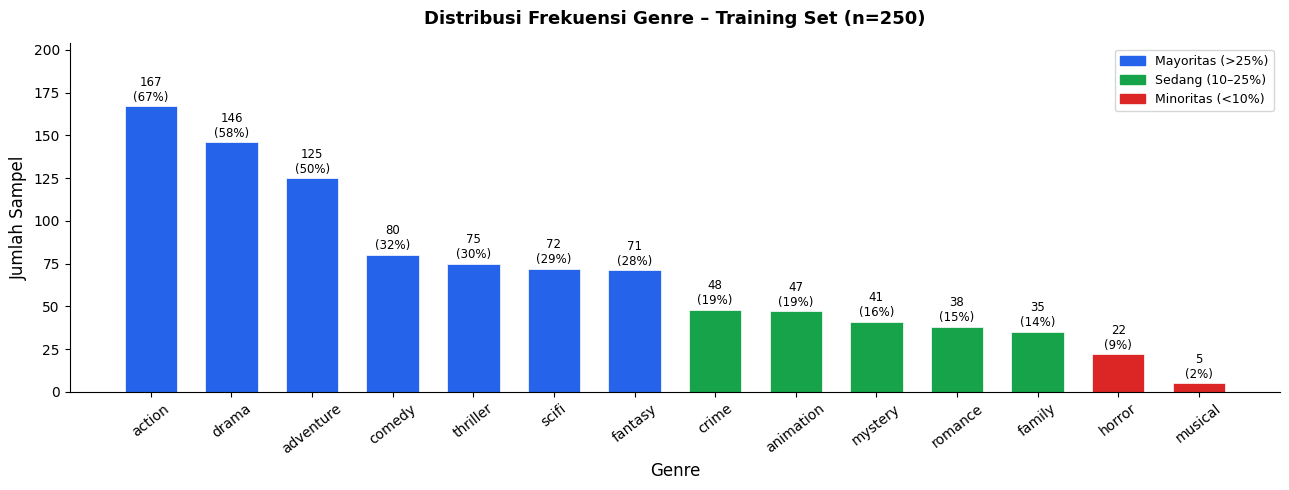


  Plot disimpan: /kaggle/working/preprocessing_outputs/fig1_genre_distribution.png


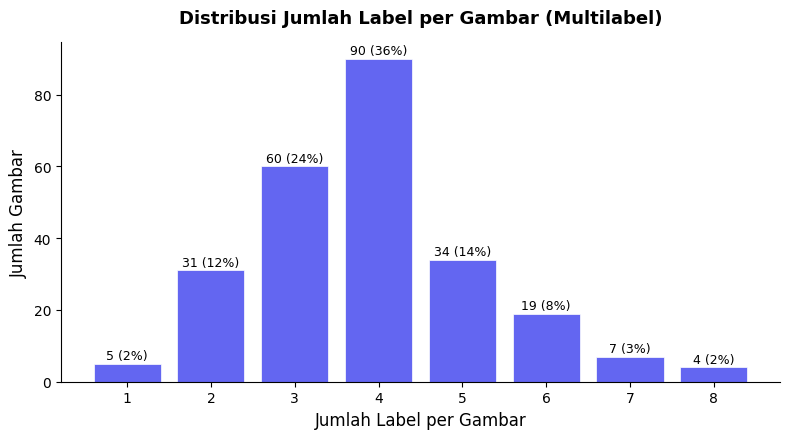

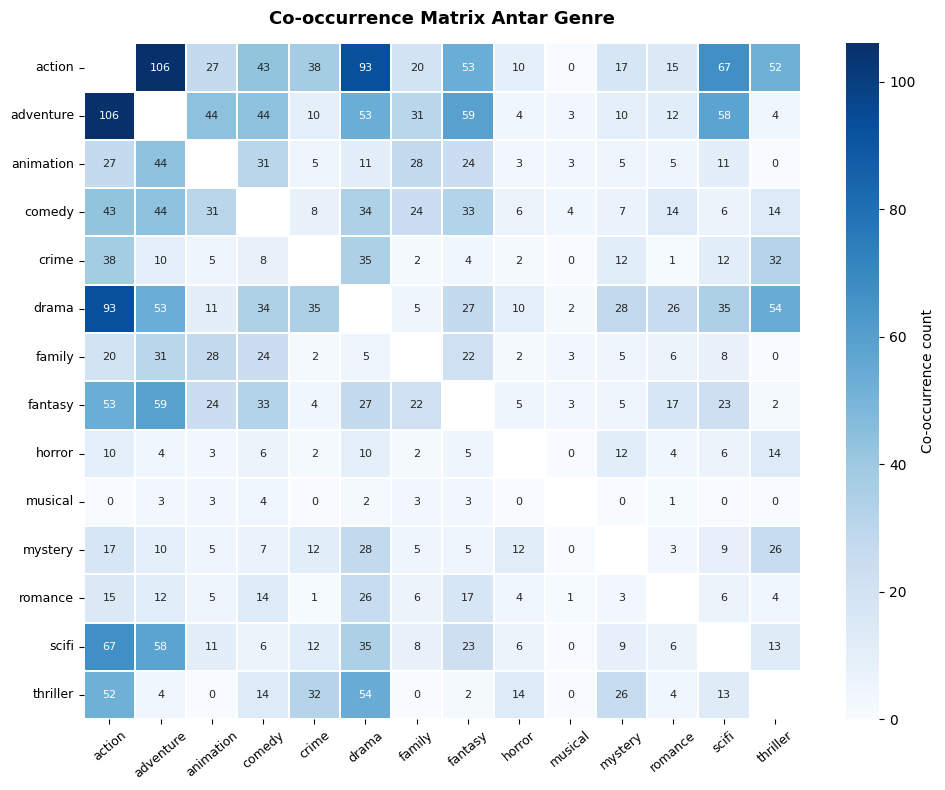

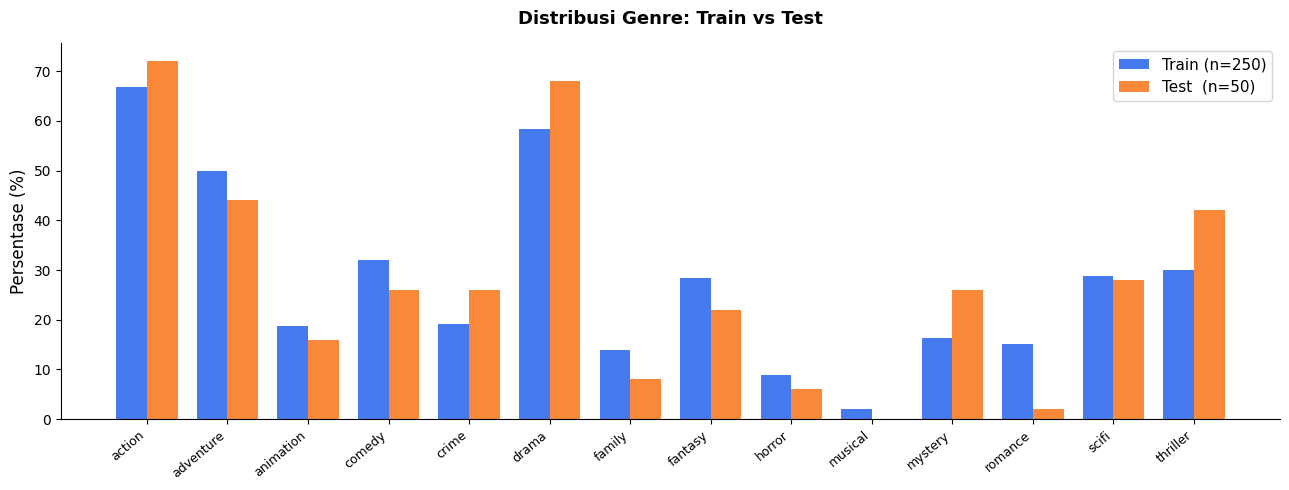

In [6]:
def analyse_distribution(df_train, df_test=None):
    """
    Menghitung dan memvisualisasikan distribusi genre.
    Menghasilkan 4 plot yang disimpan ke OUTPUT_DIR.
    """
    y     = df_train[GENRE_COLS].values.astype(int)
    n     = len(df_train)
    gc    = y.sum(axis=0)          # jumlah sampel per genre
    pct   = gc / n * 100
    lpi   = y.sum(axis=1)          # jumlah label per gambar
 
    # ── Statistik teks ──────────────────────────────────────
    print("═" * 55)
    print("  ANALISIS DISTRIBUSI LABEL — TRAINING SET")
    print("═" * 55)
    print(f"  Total sampel           : {n}")
    print(f"  Rata-rata label/gambar : {lpi.mean():.2f}")
    print(f"  Median  label/gambar   : {np.median(lpi):.1f}")
    print(f"  Min / Max label/gambar : {int(lpi.min())} / {int(lpi.max())}")
 
    ir = gc.max() / max(gc.min(), 1)
    print(f"  Imbalance ratio        : {ir:.1f}×  "
          f"({GENRE_COLS[gc.argmax()]} vs {GENRE_COLS[gc.argmin()]})")
 
    print(f"\n  {'Genre':<12} {'Count':>5} {'%':>6}  {'Kategori'}")
    print("  " + "─" * 40)
    order = np.argsort(gc)[::-1]
    for i in order:
        cat = ("Mayoritas" if pct[i] > 25
               else "Sedang" if pct[i] >= 10
               else "Minoritas ⚠")
        bar = "█" * int(pct[i] / 3)
        print(f"  {GENRE_COLS[i]:<12} {gc[i]:>5} {pct[i]:>5.1f}%  "
              f"{bar:<20} {cat}")
 
    print(f"\n  Distribusi jumlah label per gambar:")
    vals, cnts = np.unique(lpi, return_counts=True)
    for v, c in zip(vals, cnts):
        print(f"    {int(v)} label : {c:3d} gambar ({c/n*100:.1f}%)")
 
    # Plot 1: Distribusi genre
    def bar_color(p):
        return "#2563EB" if p > 25 else "#16A34A" if p >= 10 else "#DC2626"
 
    fig, ax = plt.subplots(figsize=(13, 5))
    g_ord   = [GENRE_COLS[i] for i in order]
    c_ord   = gc[order]
    p_ord   = pct[order]
    colors  = [bar_color(p) for p in p_ord]
 
    bars = ax.bar(g_ord, c_ord, color=colors, width=0.65,
                  edgecolor="white", linewidth=0.5)
    for bar, cnt, p in zip(bars, c_ord, p_ord):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{cnt}\n({p:.0f}%)",
                ha="center", va="bottom", fontsize=8.5)
    ax.set_ylim(0, c_ord.max() * 1.22)
    ax.set_xlabel("Genre", fontsize=12)
    ax.set_ylabel("Jumlah Sampel", fontsize=12)
    ax.set_title(f"Distribusi Frekuensi Genre – Training Set (n={n})",
                 fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(axis="x", rotation=38)
    ax.spines[["top","right"]].set_visible(False)
    patches = [
        mpatches.Patch(color="#2563EB", label="Mayoritas (>25%)"),
        mpatches.Patch(color="#16A34A", label="Sedang (10–25%)"),
        mpatches.Patch(color="#DC2626", label="Minoritas (<10%)"),
    ]
    ax.legend(handles=patches, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig1_genre_distribution.png", dpi=180)
    plt.show()
    print(f"\n  Plot disimpan: {OUTPUT_DIR}/fig1_genre_distribution.png")
 
    # Plot 2: Label per gambar 
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar([str(int(v)) for v in vals], cnts,
                  color="#6366F1", edgecolor="white", linewidth=0.5)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{cnt} ({cnt/n*100:.0f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("Jumlah Label per Gambar", fontsize=12)
    ax.set_ylabel("Jumlah Gambar", fontsize=12)
    ax.set_title("Distribusi Jumlah Label per Gambar (Multilabel)",
                 fontsize=13, fontweight="bold", pad=14)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig2_labels_per_image.png", dpi=180)
    plt.show()
 
    # Plot 3: Co-occurrence matrix
    comat = pd.DataFrame(y, columns=GENRE_COLS).T.dot(
            pd.DataFrame(y, columns=GENRE_COLS))
    mask  = np.eye(N_GENRES, dtype=bool)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(comat, mask=mask, annot=True, fmt="d",
                cmap="Blues", ax=ax, linewidths=0.3,
                linecolor="white", annot_kws={"size": 8},
                cbar_kws={"label": "Co-occurrence count"})
    ax.set_title("Co-occurrence Matrix Antar Genre",
                 fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig3_cooccurrence.png", dpi=180)
    plt.show()
 
    # Plot 4: Train vs Test distribution
    if df_test is not None:
        y_test   = df_test[GENRE_COLS].values.astype(int)
        test_pct = y_test.sum(axis=0) / len(df_test) * 100
        x        = np.arange(N_GENRES)
        w        = 0.38
        fig, ax  = plt.subplots(figsize=(13, 5))
        ax.bar(x - w/2, pct,      w, label="Train (n=250)",
               color="#2563EB", alpha=0.85)
        ax.bar(x + w/2, test_pct, w, label="Test  (n=50)",
               color="#F97316", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(GENRE_COLS, rotation=40, ha="right", fontsize=9)
        ax.set_ylabel("Persentase (%)", fontsize=12)
        ax.set_title("Distribusi Genre: Train vs Test",
                     fontsize=13, fontweight="bold", pad=14)
        ax.legend(fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "fig4_train_vs_test.png", dpi=180)
        plt.show()
 
    return {"genre_counts": gc, "genre_pct": pct, "labels_per_img": lpi}

eda_stats = analyse_distribution(df_train, df_test)

In [7]:
def stratified_split(df_train, val_ratio=VAL_RATIO, seed=RANDOM_SEED):
    """
    Membagi df_train menjadi train dan validation.
 
    Menggunakan IterativeStratification dari scikit-multilearn
    untuk menjaga proporsi genre di kedua subset.
    Ini penting karena genre seperti 'musical' hanya punya 5 sampel —
    kalau split random, bisa saja 0 sampel musical masuk ke val.
    """
    try:
        from skmultilearn.model_selection import iterative_train_test_split
 
        X = df_train[["filename"]].values   # shape (250, 1)
        y = df_train[GENRE_COLS].values     # shape (250, 14)
 
        X_tr, y_tr, X_val, y_val = iterative_train_test_split(
            X, y, test_size=val_ratio
        )
 
        train_fnames = X_tr.flatten().tolist()
        val_fnames   = X_val.flatten().tolist()
 
        df_tr  = df_train[df_train["filename"].isin(train_fnames)].copy().reset_index(drop=True)
        df_val = df_train[df_train["filename"].isin(val_fnames)].copy().reset_index(drop=True)
        method = "IterativeStratification ✓"
 
    except Exception as e:
        print(f"  ⚠ scikit-multilearn error: {e}")
        print("  Menggunakan random split sebagai fallback...")
        df_tr, df_val = train_test_split(
            df_train, test_size=val_ratio, random_state=seed, shuffle=True
        )
        df_tr  = df_tr.reset_index(drop=True)
        df_val = df_val.reset_index(drop=True)
        method = "RandomSplit (fallback)"
 
    print(f"\nStratified Split — Metode: {method}")
    print(f"  Train : {len(df_tr):3d} sampel")
    print(f"  Val   : {len(df_val):3d} sampel")
 
    # Verifikasi proporsi genre
    print(f"\n  Verifikasi proporsi genre (train% | val% | selisih):")
    y_tr_arr  = df_tr[GENRE_COLS].values
    y_val_arr = df_val[GENRE_COLS].values
    for i, g in enumerate(GENRE_COLS):
        ptr  = y_tr_arr[:, i].sum()  / len(df_tr)  * 100
        pv   = y_val_arr[:, i].sum() / len(df_val) * 100
        diff = abs(ptr - pv)
        flag = "  ← ⚠ gap besar" if diff > 15 else ""
        print(f"    {g:<12}: {ptr:5.1f}% | {pv:5.1f}%  "
              f"(Δ {diff:.1f}%){flag}")
 
    return df_tr, df_val
 
df_tr, df_val = stratified_split(df_train)


Stratified Split — Metode: IterativeStratification ✓
  Train : 200 sampel
  Val   :  50 sampel

  Verifikasi proporsi genre (train% | val% | selisih):
    action      :  66.0% |  70.0%  (Δ 4.0%)
    adventure   :  50.0% |  50.0%  (Δ 0.0%)
    animation   :  18.5% |  20.0%  (Δ 1.5%)
    comedy      :  32.0% |  32.0%  (Δ 0.0%)
    crime       :  19.0% |  20.0%  (Δ 1.0%)
    drama       :  58.5% |  58.0%  (Δ 0.5%)
    family      :  14.0% |  14.0%  (Δ 0.0%)
    fantasy     :  28.0% |  30.0%  (Δ 2.0%)
    horror      :   9.5% |   6.0%  (Δ 3.5%)
    musical     :   2.0% |   2.0%  (Δ 0.0%)
    mystery     :  16.5% |  16.0%  (Δ 0.5%)
    romance     :  14.5% |  18.0%  (Δ 3.5%)
    scifi       :  29.0% |  28.0%  (Δ 1.0%)
    thriller    :  28.5% |  36.0%  (Δ 7.5%)


In [8]:
def compute_weights(df_tr):
    """
    Menghitung dua jenis bobot:
 
    (A) sample_weights — untuk WeightedRandomSampler
        Genre langka → bobot tinggi → DataLoader memilihnya lebih sering
        → oversampling implisit tanpa menduplikasi file
 
    (B) pos_weight — untuk BCEWithLogitsLoss
        Genre langka → pos_weight tinggi → loss lebih besar jika salah prediksi
        Digunakan langsung di loss function saat training
    """
    y     = df_tr[GENRE_COLS].values.astype(float)
    n     = len(y)
    gc    = y.sum(axis=0)                          # count positif per genre
    nc    = n - gc                                 # count negatif per genre
 
    # pos_weight: rasio negatif/positif per genre
    pos_weight = torch.tensor(nc / np.maximum(gc, 1), dtype=torch.float32)
 
    # genre_weights: berbanding terbalik dengan frekuensi
    genre_w = n / np.maximum(gc, 1)
 
    # sample_weights: rata-rata bobot genre yang dimiliki tiap sampel
    sw = []
    for labels in y:
        idx = np.where(labels == 1)[0]
        sw.append(genre_w[idx].mean() if len(idx) > 0 else 1.0)
    sample_weights = torch.tensor(sw, dtype=torch.float32)
 
    print("Bobot genre (semakin langka = bobot semakin tinggi):")
    order = np.argsort(genre_w)[::-1]
    for i in order:
        bar = "█" * int(min(genre_w[i], 40) / 2)
        print(f"  {GENRE_COLS[i]:<12}: genre_w={genre_w[i]:6.2f}  "
              f"pos_weight={pos_weight[i]:.2f}  {bar}")
 
    print(f"\nSample weights — "
          f"min: {sample_weights.min():.3f} | "
          f"max: {sample_weights.max():.3f} | "
          f"mean: {sample_weights.mean():.3f}")
    print("\nArtinya: sampel yang mengandung 'musical' atau 'horror'")
    print("akan ~lebih sering dipilih DataLoader dibanding sampel 'action' saja.")
 
    return sample_weights, pos_weight

sample_weights, pos_weight = compute_weights(df_tr)
 
# Simpan pos_weight
print(f"\npos_weight disimpan, shape: {pos_weight.shape}")
print("Gunakan di training loop:")
print("  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))")

Bobot genre (semakin langka = bobot semakin tinggi):
  musical     : genre_w= 50.00  pos_weight=49.00  ████████████████████
  horror      : genre_w= 10.53  pos_weight=9.53  █████
  family      : genre_w=  7.14  pos_weight=6.14  ███
  romance     : genre_w=  6.90  pos_weight=5.90  ███
  mystery     : genre_w=  6.06  pos_weight=5.06  ███
  animation   : genre_w=  5.41  pos_weight=4.41  ██
  crime       : genre_w=  5.26  pos_weight=4.26  ██
  fantasy     : genre_w=  3.57  pos_weight=2.57  █
  thriller    : genre_w=  3.51  pos_weight=2.51  █
  scifi       : genre_w=  3.45  pos_weight=2.45  █
  comedy      : genre_w=  3.12  pos_weight=2.12  █
  adventure   : genre_w=  2.00  pos_weight=1.00  █
  drama       : genre_w=  1.71  pos_weight=0.71  
  action      : genre_w=  1.52  pos_weight=0.52  

Sample weights — min: 1.612 | max: 25.855 | mean: 3.568

Artinya: sampel yang mengandung 'musical' atau 'horror'
akan ~lebih sering dipilih DataLoader dibanding sampel 'action' saja.

pos_weight disimpa

Definisikan Transform (Preprocessing & Augmentasi)

In [9]:
train_transform = transforms.Compose([
    # Resize
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
 
    # Augmentasi (train saja)
    transforms.RandomHorizontalFlip(p=0.5),
 
    transforms.ColorJitter(
        brightness=0.3,   # variasi kecerahan ±30%
        contrast=0.3,     # variasi kontras ±30%
        saturation=0.2,   # variasi saturasi ±20%
        hue=0.05,         
    ),
 
    transforms.RandomRotation(degrees=10),
 
    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.85, 1.0),   
        ratio=(0.75, 1.33),  
    ),
 
    # Konversi ke Tensor
    transforms.ToTensor(),
 
    # Normalisasi ImageNet
    transforms.Normalize(
        mean=IMAGENET_MEAN,   # [0.485, 0.456, 0.406]
        std=IMAGENET_STD,     # [0.229, 0.224, 0.225]
    ),
])
 
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
print("Transform pipeline:")
print("  train_transform : Resize → HFlip → ColorJitter → Rotation",
      "→ ResizedCrop → ToTensor → Normalize")
print("  val_transform   : Resize → ToTensor → Normalize")
print(f"\n  Input shape ke model: [batch, 3, {IMG_SIZE}, {IMG_SIZE}]")
print(f"  Normalisasi mean: {IMAGENET_MEAN}")
print(f"  Normalisasi std : {IMAGENET_STD}")

Transform pipeline:
  train_transform : Resize → HFlip → ColorJitter → Rotation → ResizedCrop → ToTensor → Normalize
  val_transform   : Resize → ToTensor → Normalize

  Input shape ke model: [batch, 3, 224, 224]
  Normalisasi mean: [0.485, 0.456, 0.406]
  Normalisasi std : [0.229, 0.224, 0.225]


In [10]:
class PosterDataset(Dataset):
    """
    Custom PyTorch Dataset untuk poster film multilabel.
 
    Cara kerja:
    - __len__     : mengembalikan jumlah gambar
    - __getitem__ : membuka SATU gambar + labelnya saat dipanggil DataLoader
    - convert('RGB') : menangani gambar RGBA, grayscale, dll. secara otomatis
    """
 
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        fname = row["filename"]
        path  = self.img_dir / fname
 
        img = Image.open(path).convert("RGB")
 
        if self.transform:
            img = self.transform(img)
 
        labels = torch.tensor(
            row[GENRE_COLS].values.astype(np.float32),
            dtype=torch.float32,
        )
        return img, labels
 
# Buat 3 dataset
train_dataset = PosterDataset(df_tr,   TRAIN_DIR, transform=train_transform)
val_dataset   = PosterDataset(df_val,  TRAIN_DIR, transform=val_transform)
test_dataset  = PosterDataset(df_test, TEST_DIR,  transform=val_transform)
 
print(f"Dataset berhasil dibuat:")
print(f"  train_dataset : {len(train_dataset)} sampel  (dengan augmentasi)")
print(f"  val_dataset   : {len(val_dataset)} sampel  (tanpa augmentasi)")
print(f"  test_dataset  : {len(test_dataset)} sampel  (tanpa augmentasi)")
 
# coba load satu gambar dari dataset
sample_img, sample_labels = train_dataset[0]
print(f"\nVerifikasi satu sampel dari train_dataset:")
print(f"  img shape  : {tuple(sample_img.shape)}  (expected: [3, 224, 224])")
print(f"  img range  : [{sample_img.min():.3f}, {sample_img.max():.3f}]")
print(f"  labels     : {sample_labels.numpy()}")
print(f"  label sum  : {sample_labels.sum():.0f} genre aktif")
active = [GENRE_COLS[i] for i, v in enumerate(sample_labels) if v == 1]
print(f"  genre aktif: {active}")

Dataset berhasil dibuat:
  train_dataset : 200 sampel  (dengan augmentasi)
  val_dataset   : 50 sampel  (tanpa augmentasi)
  test_dataset  : 50 sampel  (tanpa augmentasi)

Verifikasi satu sampel dari train_dataset:
  img shape  : (3, 224, 224)  (expected: [3, 224, 224])
  img range  : [-2.118, 2.483]
  labels     : [1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
  label sum  : 5 genre aktif
  genre aktif: ['action', 'comedy', 'crime', 'drama', 'thriller']


In [11]:
# Build DataLoaders dengan WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,   
)
 
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,  
    num_workers = NUM_WORKERS,
    pin_memory  = True,     
    drop_last   = True,     
)
 
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,    
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)
 
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)
 
print("DataLoader berhasil dibuat:")
print(f"  train_loader : {len(train_loader)} batch/epoch × {BATCH_SIZE} sampel")
print(f"                 (menggunakan WeightedRandomSampler ✓)")
print(f"  val_loader   : {len(val_loader)} batch × {BATCH_SIZE} sampel")
print(f"  test_loader  : {len(test_loader)} batch × {BATCH_SIZE} sampel")

DataLoader berhasil dibuat:
  train_loader : 6 batch/epoch × 32 sampel
                 (menggunakan WeightedRandomSampler ✓)
  val_loader   : 2 batch × 32 sampel
  test_loader  : 2 batch × 32 sampel


In [12]:
# CELL 12 — Verifikasi akhir: cek output DataLoader

def verify_loader(loader, name, n_batches=2):
    print(f"\nVerifikasi '{name}':")
    genre_counts_batches = np.zeros(N_GENRES, dtype=int)
 
    for b_idx, (imgs, labels) in enumerate(loader):
        if b_idx >= n_batches:
            break
        bs = imgs.shape[0]
        print(f"  Batch {b_idx+1}:")
        print(f"    imgs.shape   : {tuple(imgs.shape)}"
              f"  {'✓' if imgs.shape == (bs,3,IMG_SIZE,IMG_SIZE) else '✗'}")
        print(f"    labels.shape : {tuple(labels.shape)}"
              f"  {'✓' if labels.shape == (bs, N_GENRES) else '✗'}")
        print(f"    nilai min/max: {imgs.min():.3f} / {imgs.max():.3f}"
              f"  (nilai negatif normal setelah normalisasi)")
        print(f"    labels dtype : {labels.dtype}"
              f"  {'✓' if labels.dtype == torch.float32 else '✗'}")
 
        batch_gc = labels.numpy().sum(axis=0).astype(int)
        genre_counts_batches += batch_gc
        active = [(GENRE_COLS[i], int(batch_gc[i]))
                  for i in range(N_GENRES) if batch_gc[i] > 0]
        print(f"    genre dalam batch: "
              + ", ".join(f"{g}({c})" for g, c in active))
 
    print(f"\n  Akumulasi {n_batches} batch pertama:")
    for i, g in enumerate(GENRE_COLS):
        print(f"    {g:<12}: {genre_counts_batches[i]}")
 
verify_loader(train_loader, "train_loader", n_batches=3)
verify_loader(val_loader,   "val_loader",   n_batches=1)
verify_loader(test_loader,  "test_loader",  n_batches=1)


Verifikasi 'train_loader':
  Batch 1:
    imgs.shape   : (32, 3, 224, 224)  ✓
    labels.shape : (32, 14)  ✓
    nilai min/max: -2.118 / 2.640  (nilai negatif normal setelah normalisasi)
    labels dtype : torch.float32  ✓
    genre dalam batch: action(18), adventure(17), animation(9), comedy(15), crime(3), drama(18), family(5), fantasy(16), horror(5), musical(1), mystery(8), romance(9), scifi(5), thriller(6)
  Batch 2:
    imgs.shape   : (32, 3, 224, 224)  ✓
    labels.shape : (32, 14)  ✓
    nilai min/max: -2.118 / 2.640  (nilai negatif normal setelah normalisasi)
    labels dtype : torch.float32  ✓
    genre dalam batch: action(17), adventure(16), animation(7), comedy(9), crime(7), drama(19), family(8), fantasy(10), horror(3), musical(4), mystery(6), romance(9), scifi(10), thriller(10)
  Batch 3:
    imgs.shape   : (32, 3, 224, 224)  ✓
    labels.shape : (32, 14)  ✓
    nilai min/max: -2.118 / 2.640  (nilai negatif normal setelah normalisasi)
    labels dtype : torch.float32  ✓
   

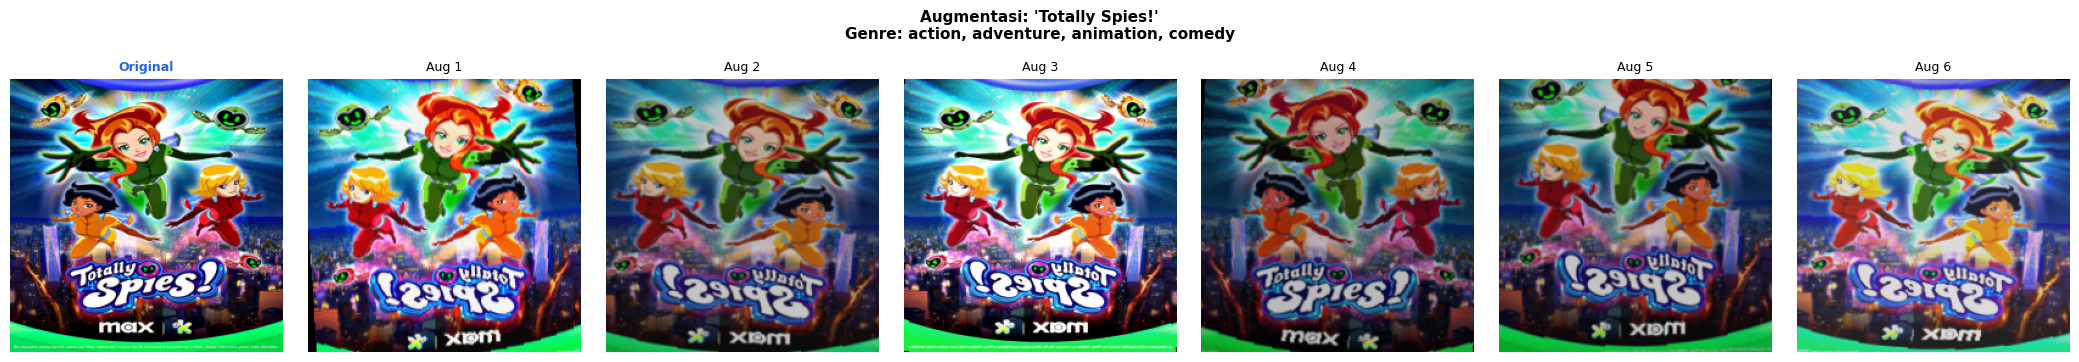

Plot disimpan: /kaggle/working/preprocessing_outputs/fig5_augmentation_samples.png


In [13]:
# CELL 13 — Visualisasi augmentasi (opsional, untuk laporan)

def visualize_augmentation(df_tr, img_dir, n_aug=6):
    """
    Tampilkan 1 gambar asli vs beberapa hasil augmentasi.
    Berguna untuk laporan: bukti bahwa augmentasi menghasilkan variasi.
    """
    # Pilih satu gambar random
    idx   = np.random.randint(len(df_tr))
    row   = df_tr.iloc[idx]
    path  = Path(img_dir) / row["filename"]
    title = row.get("title", row["filename"])
    genres = [g for g in GENRE_COLS if row[g] == 1]
 
    original = Image.open(path).convert("RGB")
 
    # Transform untuk visualisasi
    aug_for_viz = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.2, hue=0.05),
        transforms.RandomRotation(degrees=10),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    ])
 
    fig, axes = plt.subplots(1, n_aug + 1, figsize=(3 * (n_aug+1), 3.5))
 
    # Gambar asli (kiri)
    orig_resized = original.resize((IMG_SIZE, IMG_SIZE))
    axes[0].imshow(orig_resized)
    axes[0].set_title("Original", fontsize=9, fontweight="bold", color="#2563EB")
    axes[0].axis("off")
 
    # Hasil augmentasi
    for i in range(n_aug):
        aug_img = aug_for_viz(original)
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(f"Aug {i+1}", fontsize=9)
        axes[i+1].axis("off")
 
    fig.suptitle(
        f"Augmentasi: '{title}'\nGenre: {', '.join(genres)}",
        fontsize=11, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig5_augmentation_samples.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot disimpan: {OUTPUT_DIR}/fig5_augmentation_samples.png")
 
visualize_augmentation(df_tr, TRAIN_DIR, n_aug=6)

In [14]:
# Simpan hasil preprocessing ke file
# Cell ini menyimpan semua tensor yang dibutuhkan untuk training

import torch
from pathlib import Path

SAVE_DIR = Path("/kaggle/working")

print("Menyimpan hasil preprocessing...")
print("Ini mungkin memakan waktu beberapa menit...\n")

# ── Fungsi untuk mengumpulkan semua data dari DataLoader ──────────
def collect_all_data(loader, desc=""):
    """
    Mengumpulkan semua gambar dan label dari DataLoader
    menjadi satu tensor besar.
    """
    all_imgs   = []
    all_labels = []
    total = len(loader)

    for i, (imgs, labels) in enumerate(loader):
        all_imgs.append(imgs)
        all_labels.append(labels)
        if (i + 1) % 5 == 0 or (i + 1) == total:
            print(f"  {desc}: batch {i+1}/{total} selesai")

    imgs_tensor   = torch.cat(all_imgs,   dim=0)
    labels_tensor = torch.cat(all_labels, dim=0)
    return imgs_tensor, labels_tensor

# ── Kumpulkan data dari ketiga split ─────────────────────────────
print("Mengumpulkan data training...")
X_train, y_train = collect_all_data(train_loader, "Train")

print("\nMengumpulkan data validation...")
X_val, y_val = collect_all_data(val_loader, "Val")

print("\nMengumpulkan data test...")
X_test, y_test = collect_all_data(test_loader, "Test")

# ── Tampilkan informasi tensor ────────────────────────────────────
print(f"\nShape hasil preprocessing:")
print(f"  X_train : {X_train.shape}   dtype: {X_train.dtype}")
print(f"  y_train : {y_train.shape}   dtype: {y_train.dtype}")
print(f"  X_val   : {X_val.shape}")
print(f"  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

# Verifikasi nilai pixel sudah ternormalisasi
print(f"\nVerifikasi normalisasi:")
print(f"  X_train min: {X_train.min():.3f}  max: {X_train.max():.3f}")
print(f"  (nilai negatif dan >1 adalah normal setelah normalisasi ImageNet)")

Menyimpan hasil preprocessing...
Ini mungkin memakan waktu beberapa menit...

Mengumpulkan data training...
  Train: batch 5/6 selesai
  Train: batch 6/6 selesai

Mengumpulkan data validation...
  Val: batch 2/2 selesai

Mengumpulkan data test...
  Test: batch 2/2 selesai

Shape hasil preprocessing:
  X_train : torch.Size([192, 3, 224, 224])   dtype: torch.float32
  y_train : torch.Size([192, 14])   dtype: torch.float32
  X_val   : torch.Size([50, 3, 224, 224])
  y_val   : torch.Size([50, 14])
  X_test  : torch.Size([50, 3, 224, 224])
  y_test  : torch.Size([50, 14])

Verifikasi normalisasi:
  X_train min: -2.118  max: 2.640
  (nilai negatif dan >1 adalah normal setelah normalisasi ImageNet)


In [15]:
# Simpan ke file .pt

# ── Simpan dalam SATU file (lebih praktis untuk dibagikan) ────────
save_path = SAVE_DIR / "preprocessed_data.pt"

torch.save({
    # Data gambar (sudah di-resize, augmentasi, dan normalisasi)
    "X_train" : X_train,    # shape: [~200, 3, 224, 224]
    "y_train" : y_train,    # shape: [~200, 14]
    "X_val"   : X_val,      # shape: [~50,  3, 224, 224]
    "y_val"   : y_val,      # shape: [~50,  14]
    "X_test"  : X_test,     # shape: [50,   3, 224, 224]
    "y_test"  : y_test,     # shape: [50,   14]

    # Metadata penting untuk training
    "genre_cols"  : GENRE_COLS,          # list 14 nama genre
    "pos_weight"  : pos_weight,          # untuk BCEWithLogitsLoss
    "sample_weights": sample_weights,    # untuk WeightedRandomSampler

    # Informasi split untuk dokumentasi
    "split_info" : {
        "n_train" : len(X_train),
        "n_val"   : len(X_val),
        "n_test"  : len(X_test),
    },

    # Informasi preprocessing untuk reproduksibilitas
    "preprocessing_info": {
        "img_size"      : IMG_SIZE,           # 224
        "imagenet_mean" : IMAGENET_MEAN,      # [0.485, 0.456, 0.406]
        "imagenet_std"  : IMAGENET_STD,       # [0.229, 0.224, 0.225]
        "val_ratio"     : VAL_RATIO,          # 0.2
        "random_seed"   : RANDOM_SEED,        # 42
        "augmentation"  : [
            "RandomHorizontalFlip(p=0.5)",
            "ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05)",
            "RandomRotation(10)",
            "RandomResizedCrop(224, scale=(0.85,1.0))"
        ],
        "note": "X_train sudah melalui augmentasi. X_val dan X_test hanya resize+normalize."
    }
}, save_path)

file_size_mb = save_path.stat().st_size / (1024 * 1024)
print(f"File disimpan: {save_path}")
print(f"Ukuran file  : {file_size_mb:.1f} MB")
print(f"\nFile ini berisi semua yang dibutuhkan untuk training:")
print(f"  - X_train, y_train : data training siap pakai")
print(f"  - X_val, y_val     : data validation siap pakai")
print(f"  - X_test, y_test   : data test siap pakai")
print(f"  - pos_weight       : untuk loss function")
print(f"  - genre_cols       : nama 14 genre")

File disimpan: /kaggle/working/preprocessed_data.pt
Ukuran file  : 167.7 MB

File ini berisi semua yang dibutuhkan untuk training:
  - X_train, y_train : data training siap pakai
  - X_val, y_val     : data validation siap pakai
  - X_test, y_test   : data test siap pakai
  - pos_weight       : untuk loss function
  - genre_cols       : nama 14 genre
